Den her fejler fortsat lidt over dete hele ...

In [2]:
import numpy as np
from active_learning import run_active_learning
import matplotlib.pyplot as plt

<!-- scores, labeled_sizes, best_model, best_acc = run_active_learning(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=5,
    query_size=10,
    strategy="entropy",
    paradigm="active learning",
    batch_size=64,
    epochs=2,
    lr=1e-3,
    seed=42,
) -->

Uncertainty sampling
> Comparing entropy, least confidence and margin with just random sampling. With an initial training set of 100 images, we query 10 more images at every iteration by picking data points from the pool based on the three differetn strategies. 


=== Iteration 1/3 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/1  Loss: 4.617
Test accuracy: 0.1000

=== Iteration 2/3 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/1  Loss: 4.608
Test accuracy: 0.1429

=== Iteration 3/3 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/1  Loss: 4.624
Test accuracy: 0.1609


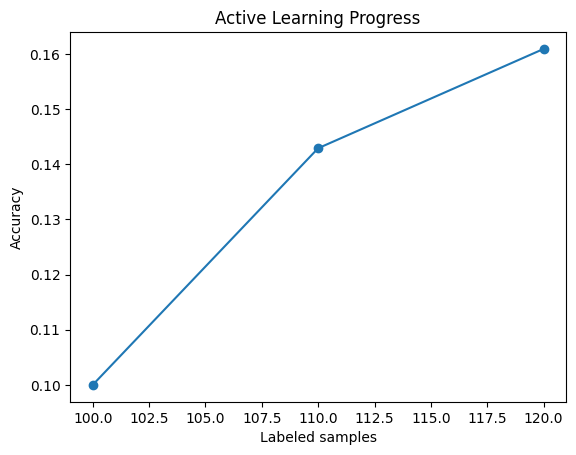

In [3]:
scores, labeled_sizes, best_model, best_acc = run_active_learning(
    n_initial_per_class=10,
    n_iterations=3,
    query_size=10,
    epochs=1,
)

plt.plot(labeled_sizes, scores, marker='o')
plt.xlabel("Labeled samples")
plt.ylabel("Accuracy")
plt.title("Active Learning Progress")
plt.show()


=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/1  Loss: 4.611
Test accuracy: 0.0991

=== Iteration 2/10 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/1  Loss: 4.615
Test accuracy: 0.1015

=== Iteration 3/10 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/1  Loss: 4.622
Test accuracy: 0.1000

=== Iteration 4/10 ===
Labeled set size: 130
Pool size:        49870
Epoch 1/1  Loss: 6.859
Test accuracy: 0.1000

=== Iteration 5/10 ===
Labeled set size: 140
Pool size:        49860
Epoch 1/1  Loss: 6.926
Test accuracy: 0.1000

=== Iteration 6/10 ===
Labeled set size: 150
Pool size:        49850
Epoch 1/1  Loss: 6.907
Test accuracy: 0.1040

=== Iteration 7/10 ===
Labeled set size: 160
Pool size:        49840
Epoch 1/1  Loss: 6.890
Test accuracy: 0.1000

=== Iteration 8/10 ===
Labeled set size: 170
Pool size:        49830
Epoch 1/1  Loss: 6.896
Test accuracy: 0.1000

=== Iteration 9/10 ===
Labeled set size: 180
Pool size:        49820
Epoch 1/1 

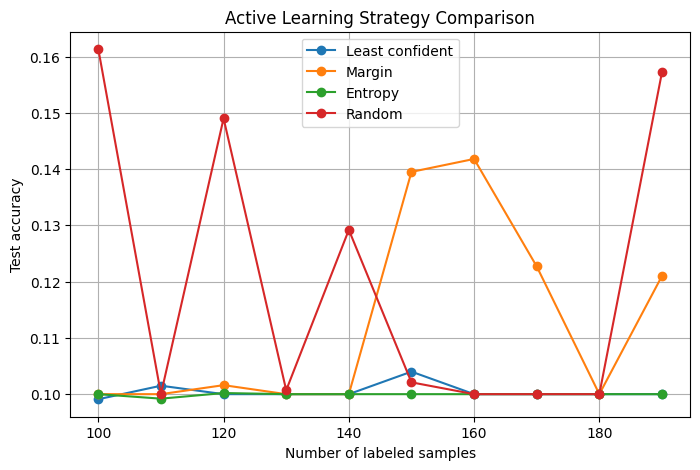

Best accuracies:
Least confident: 0.1040
Margin:          0.1418
Entropy:         0.1002
Random:          0.1613


In [ ]:
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Common settings
common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=10,
    query_size=10,
    batch_size=64,
    epochs=1,     # increase later if you want
    lr=1e-3,
    seed=42,
)

# Run active learning with the three uncertainty strategies
scores_lc, labeled_lc, best_model_lc, best_acc_lc = run_active_learning(
    strategy="least confident",
    paradigm="active learning",
    **common_kwargs
)

scores_margin, labeled_margin, best_model_margin, best_acc_margin = run_active_learning(
    strategy="margin",
    paradigm="active learning",
    **common_kwargs
)

scores_entropy, labeled_entropy, best_model_entropy, best_acc_entropy = run_active_learning(
    strategy="entropy",
    paradigm="active learning",
    **common_kwargs
)

# Run random sampling baseline
scores_random, labeled_random, best_model_random, best_acc_random = run_active_learning(
    paradigm="random",
    **common_kwargs
)

# Plot all curves together
plt.figure(figsize=(8, 5))

plt.plot(labeled_lc, scores_lc, marker='o', label='Least confident')
plt.plot(labeled_margin, scores_margin, marker='o', label='Margin')
plt.plot(labeled_entropy, scores_entropy, marker='o', label='Entropy')
plt.plot(labeled_random, scores_random, marker='o', label='Random')

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning Strategy Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Print best accuracies too
print("Best accuracies:")
print(f"Least confident: {best_acc_lc:.4f}")
print(f"Margin:          {best_acc_margin:.4f}")
print(f"Entropy:         {best_acc_entropy:.4f}")
print(f"Random:          {best_acc_random:.4f}")

Running each iteration multiple times and computing averages to get more robust graphs that are less sensitive towards initialisation:


Running averaged experiment: Least confident
  Run 1/5

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/1  Loss: 4.599
Test accuracy: 0.1022

=== Iteration 2/10 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/1  Loss: 4.621
Test accuracy: 0.1320

=== Iteration 3/10 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/1  Loss: 4.617
Test accuracy: 0.1322

=== Iteration 4/10 ===
Labeled set size: 130
Pool size:        49870
Epoch 1/1  Loss: 6.936
Test accuracy: 0.1000

=== Iteration 5/10 ===
Labeled set size: 140
Pool size:        49860
Epoch 1/1  Loss: 6.922
Test accuracy: 0.1018

=== Iteration 6/10 ===
Labeled set size: 150
Pool size:        49850
Epoch 1/1  Loss: 6.942
Test accuracy: 0.1000

=== Iteration 7/10 ===
Labeled set size: 160
Pool size:        49840
Epoch 1/1  Loss: 6.909
Test accuracy: 0.1000

=== Iteration 8/10 ===
Labeled set size: 170
Pool size:        49830
Epoch 1/1  Loss: 6.931
Test accuracy: 0.1000

=== Iteration 9/10 ===


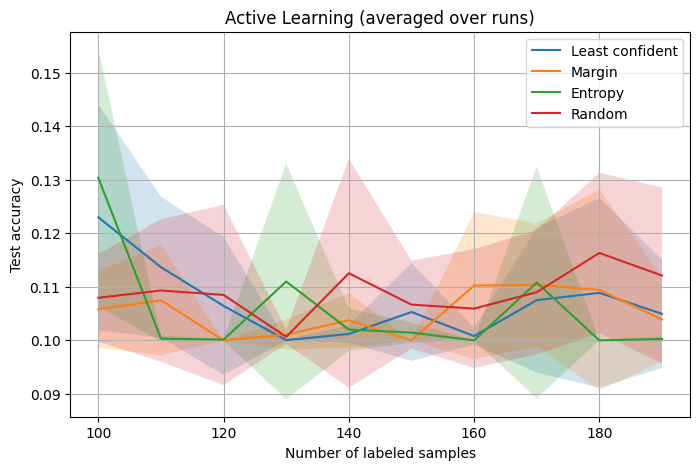

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 5          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=1,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 5          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 3

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=5,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()